# Inputs for Neural Net
- Type of game played
- Length of game (time and moves)
- Game outcomes
    - Winner
    - Type of outcome
- Move evaluation
    - Variance
    - Mean
    - IQR
    - Next best moves
        - Mean
        - Did they choose the best move?
        - Did they choose the next best move?
- Piece evaluation
    - Number of moves of each piece
    - Captures per piece
    - Number of checks
    - Checks per piece
    - Breakdown per part of the game

# Environment Notes
To get the project to run properly, the python version needs to be set to 3.11. Create a fresh conda envioronment. Run the following commands:
```bash
conda create -n chess python-3.11
conda activate chess
pip install pandas
pip install matplotlib
pip install seaborn
pip install chess
pip install tensorflow
```

In [3]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chess

# Loading and Cleaning

In [4]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

chess_data_raw = chess_data_raw[chess_data_raw['turns'] >= 4]

chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Add column for average player ELO per game
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Add column to bucket games by rating 
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

print(chess_data.shape)
chess_data.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')
(15943, 12)


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


In [5]:
# -------------------------------------------------------
# Use Python Chess to get parameters for neural net
# -------------------------------------------------------


def board_analysis(movelist):
    piece_lookup = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0,
    }
    colors = ["white", "black"]
    categories = [
        "moves",
        "captures",
        "checks",
        "forks",
        "pins",
        "attacks",
        "defenses",
        "center_control_turns",
    ]
    pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    analysis = {
        color: {
            category: {piece: 0 for piece in pieces}
            for category in categories
        }
        for color in colors
    }
    promotion_counts = {color: 0 for color in colors}
    forced_move_counts = {color: 0 for color in colors}
    material_taken = {color: 0 for color in colors}
    material_lost = {color: 0 for color in colors}

    board = chess.Board()

    for san in movelist:
        try:
            move = board.parse_san(san)
        except Exception:
            break

        color = "white" if board.turn == chess.WHITE else "black"
        opponent_color = "black" if color == "white" else "white"
        piece = board.piece_at(move.from_square)

        if piece is None:
            break

        piece_name = piece_lookup[piece.piece_type]
        analysis[color]["moves"][piece_name] += 1

        captured_value = 0
        if board.is_capture(move):
            analysis[color]["captures"][piece_name] += 1
            if board.is_en_passant(move):
                captured_value = piece_values[chess.PAWN]
            else:
                captured_piece = board.piece_at(move.to_square)
                if captured_piece is not None:
                    captured_value = piece_values[captured_piece.piece_type]

        material_taken[color] += captured_value
        material_lost[opponent_color] += captured_value

        board.push(move)

        if board.is_check():
            analysis[color]["checks"][piece_name] += 1

        attacked_enemy_pieces = 0
        defended_friendly_pieces = 0
        pinned_enemy_pieces = 0
        for square in board.attacks(move.to_square):
            target_piece = board.piece_at(square)
            if target_piece is None:
                continue
            if target_piece.color != piece.color:
                attacked_enemy_pieces += 1
                if board.is_pinned(target_piece.color, square):
                    pinned_enemy_pieces += 1
            else:
                defended_friendly_pieces += 1

        analysis[color]["attacks"][piece_name] += attacked_enemy_pieces
        analysis[color]["defenses"][piece_name] += defended_friendly_pieces

        if attacked_enemy_pieces >= 2:
            analysis[color]["forks"][piece_name] += 1

        if pinned_enemy_pieces > 0:
            analysis[color]["pins"][piece_name] += pinned_enemy_pieces

        if move.promotion is not None:
            promotion_counts[color] += 1

        if board.legal_moves.count() == 1:
            forced_move_counts[color] += 1

        for square in center_squares:
            center_piece = board.piece_at(square)
            if center_piece is None:
                continue
            center_color = "white" if center_piece.color == chess.WHITE else "black"
            center_piece_name = piece_lookup[center_piece.piece_type]
            analysis[center_color]["center_control_turns"][center_piece_name] += 1

    flattened_vector = []
    for color in colors:
        for category in categories:
            for piece in pieces:
                flattened_vector.append(analysis[color][category][piece])

    for color in colors:
        flattened_vector.extend([
            promotion_counts[color],
            forced_move_counts[color],
            material_taken[color],
            material_lost[color],
        ])

    return flattened_vector


In [6]:
colors = ["white", "black"]
categories = [
    "moves",
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]
pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
summary_metrics = ["promotions", "forced_moves", "material_taken", "material_lost"]

neural_net_columns = [
    f"{color}_{category}_{piece}"
    for color in colors
    for category in categories
    for piece in pieces
] + [
    f"{color}_{metric}"
    for color in colors
    for metric in summary_metrics
]

neural_net_columns += [
    "white_elo",
    "black_elo",
    "winner",
    "total_turns",
    "white_turns",
    "black_turns",
    "idx"
]

neural_net_rows = []

for idx, row in chess_data.iterrows():
    total_turns = row["turns"]
    white_turns = (total_turns + 1) // 2
    black_turns = total_turns // 2

    board_analysis_row = board_analysis(row["moves"])
    board_analysis_row += [
        row["white_rating"],
        row["black_rating"],
        row["winner"],
        total_turns,
        white_turns,
        black_turns,
        idx
    ]
    neural_net_rows.append(board_analysis_row)

neural_net_input = pd.DataFrame(neural_net_rows, columns=neural_net_columns)
neural_net_input.describe()


,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns,idx
count,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,...,15943.000000,15943.000000,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000
mean,8.607288,5.57831,4.966067,4.442828,4.010977,4.032052,1.841247,1.363984,1.430095,1.172803,...,0.353008,20.199272,20.374020,1599.90949,1596.395660,0.041147,62.756758,31.637521,31.119237,10121.965502
std,4.381908,3.43769,3.048665,5.252713,3.749370,5.677335,1.375202,1.241930,1.195479,1.490381,...,0.908748,11.310281,11.261918,282.71278,287.500823,0.976612,33.240935,16.615902,16.628786,5789.764497
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,784.00000,789.000000,-1.000000,4.000000,2.000000,2.000000,1.000000
25%,5.000000,3.00000,3.000000,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,11.000000,11.000000,1399.00000,1393.000000,-1.000000,39.000000,20.000000,19.000000,5159.500000
50%,8.000000,5.00000,4.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,20.000000,20.000000,1579.00000,1576.000000,0.000000,57.000000,29.000000,28.000000,10047.000000
75%,11.000000,7.00000,6.000000,6.000000,5.000000,5.000000,3.000000,2.000000,2.000000,2.000000,...,0.000000,29.000000,30.000000,1795.00000,1793.000000,1.000000,81.000000,41.000000,40.000000,15223.500000
max,35.000000,59.00000,44.000000,83.000000,41.000000,74.000000,8.000000,11.000000,11.000000,9.000000,...,16.000000,55.000000,55.000000,2622.00000,2588.000000,1.000000,349.000000,175.000000,174.000000,20057.000000


In [7]:
neural_net_input

,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns,idx
0,6,0,0,0,2,0,2,0,0,0,...,0,11,2,1322,1261,-1.0,16,8,8,1
1,12,3,8,5,3,0,7,1,3,3,...,0,7,38,1496,1500,1.0,61,31,30,2
2,4,9,4,3,10,1,1,3,2,0,...,0,8,30,1439,1454,1.0,61,31,30,3
3,13,8,3,16,4,4,1,3,1,5,...,1,30,38,1523,1469,1.0,95,48,47,4
4,3,4,5,0,4,1,0,2,0,0,...,0,9,9,1520,1423,1.0,33,17,16,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15938,3,4,3,1,0,1,0,1,1,0,...,0,4,2,1691,1220,1.0,24,12,12,20053
15939,8,11,3,2,8,9,2,3,0,0,...,1,26,25,1233,1196,-1.0,82,41,41,20054
15940,3,6,5,0,4,0,0,0,2,0,...,0,6,4,1219,1286,1.0,35,18,17,20055
15941,24,10,4,9,2,6,5,3,2,2,...,2,31,38,1360,1227,1.0,109,55,54,20056


# Nueral Network Development and Design
- Experiment with multiple types of models
- Use smaller data to test
- Find which performs the best
- Train the best performing model using large data

## Import Tensorflow and Relevant Libraries
- Using tensorflow because it is flexible and fast
- It will allow us to process the relatively large dataset (13k rows)

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Regression Model Using Board-Strategy Counts and Game Summary Features
This model predicts average game ELO using only engineered board-statistics features from the move list.

Inputs:
- Per-piece action counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Game-level summary counts for each color, including promotions, forced moves, material taken, and material lost
- Outcome and pace context from the finished game, including winner and turn counts
- No centipawn or Stockfish evaluation data

Question: Can ELO be predicted from board-state summary statistics alone, without engine evaluation features?

In [9]:
# ==============================
# Seperate data into X and y
# ==============================

neural_net_input["game_elo"] = neural_net_input[["white_elo", "black_elo"]].mean(axis=1)

feature_cols = [
    col for col in neural_net_input.columns
    if col not in ["white_elo", "black_elo", "game_elo", "idx"]
]
target_cols = ["game_elo"]

X = neural_net_input[feature_cols].values.astype(np.float32)
y = neural_net_input[target_cols].values.astype(np.float32)

# ============================================================
# Split data into test, train, and validation
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(X_train)

# ==============================
# Build model
# ==============================
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    normalizer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[keras.metrics.MeanAbsoluteError()]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# ==============================
# Train
# ==============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
pred = model.predict(X_test, verbose=0)

game_mae = mean_absolute_error(y_test[:, 0], pred[:, 0])
game_rmse = np.sqrt(mean_squared_error(y_test[:, 0], pred[:, 0]))
board_baseline_pred = np.full((len(y_test), 1), y_train_full.mean())
board_baseline_mae = mean_absolute_error(y_test[:, 0], board_baseline_pred[:, 0])
board_baseline_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {game_mae:.2f}")
print(f"Game ELO RMSE: {game_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - game_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - game_rmse:.2f}")

Epoch 1/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - loss: 875395.1875 - mean_absolute_error: 747.5107 - val_loss: 169220.8438 - val_mean_absolute_error: 328.5060
Epoch 2/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 130809.7969 - mean_absolute_error: 284.1565 - val_loss: 108497.1016 - val_mean_absolute_error: 259.1723
Epoch 3/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - loss: 103176.9219 - mean_absolute_error: 252.9160 - val_loss: 93888.6406 - val_mean_absolute_error: 240.6178
Epoch 4/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 91429.2422 - mean_absolute_error: 239.7396 - val_loss: 87297.8906 - val_mean_absolute_error: 234.3155
Epoch 5/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - loss: 84102.0859 - mean_absolute_error: 229.3398 - val_loss: 81595.1094 - val_mean_absolute_error: 228.6267
Epoch 6/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 78442.0781 - mean_absolute_error: 221.3477 - val_loss: 74837.6641 - val_mean_absolute_error: 217.7433
Epoch

# Regression Model Using the First 20 Centipawn Evaluations Per Side
This model predicts average game ELO from engine-evaluation sequences rather than handcrafted board-strategy counts.

Inputs:
- The first 20 white centipawn evaluations and first 20 black centipawn evaluations from each game
- Centipawn values clamped to reduce the impact of near-checkmate extremes
- Only games long enough to provide at least 20 evaluation points for both sides

In [10]:
import ast

# ==============================
# Data processing
# ==============================

centipawn_data = pd.read_csv("centipawn/centipawn_data_depth_12.csv")

# Clamp values (stockfish provided very high values 100000 and -100000 when checkmate was soon)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(ast.literal_eval)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(
    lambda values: [max(-1000, min(1000, value)) for value in values]
)

# Sort centipawn by color
centipawn_data["white_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[::2])
centipawn_data["black_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[1::2])

# Combine centipawn data with board-analysis features using the explicit index columns
neural_net_with_centipawn = neural_net_input.merge(
    centipawn_data,
    left_on="idx",
    right_on="index",
    how="inner"
)

centipawn_vector_input = neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40]

centipawn_vector_input = centipawn_vector_input[["white_centipawn", "black_centipawn", "white_elo", "black_elo"]].copy()
centipawn_vector_input["game_elo"] = centipawn_vector_input[["white_elo", "black_elo"]].mean(axis=1)
centipawn_vector_input

,white_centipawn,black_centipawn,white_elo,black_elo,game_elo
1,"[39, 42, 25, 18, 70, 73, 260, 506, 571, 552, 5...","[-38, 15, -6, -14, -46, -84, -268, -504, -530,...",1496,1500,1498.0
2,"[43, 37, 48, 0, 89, 133, 172, 232, 382, 437, 5...","[-34, -32, 13, -5, -69, -70, -105, -199, -262,...",1439,1454,1446.5
3,"[40, 45, 74, 91, 117, 115, 111, 82, 45, -75, -...","[-45, -43, -72, -88, -118, -115, -82, -43, 55,...",1523,1469,1496.0
5,"[47, 46, 32, 114, 53, 51, 44, 15, 10, 1, -24, ...","[-47, 12, -33, -58, -51, -41, -14, -2, -3, 21,...",1439,1392,1415.5
6,"[36, 76, 82, 89, 180, 175, 59, 159, 184, 106, ...","[-47, -73, -81, -92, -184, -66, -55, -153, -77...",1381,1209,1295.0
...,...,...,...,...,...
15934,"[41, 60, 40, 85, 54, 51, 19, 39, -4, -74, -88,...","[-36, -40, -6, -44, -30, -25, -19, 22, 87, 84,...",1328,1252,1290.0
15936,"[43, 59, 38, 7, -189, 22, -271, -350, -159, -1...","[-38, -35, 13, 254, 181, 277, 324, 442, 184, 3...",1237,1231,1234.0
15939,"[43, 64, 132, 111, 8, 23, 15, 18, 21, -28, 82,...","[-43, -48, 2, -9, -2, -4, -17, -15, 74, 22, 26...",1233,1196,1214.5
15941,"[42, 61, 66, -123, -121, -45, -62, -122, -154,...","[-40, -69, 120, 119, 130, 93, 120, 142, 213, 2...",1360,1227,1293.5


In [11]:
# ==============================
# Flatten first 20 centipawn moves per side
# ==============================
centipawn_vector_input = centipawn_vector_input[
    (centipawn_vector_input["white_centipawn"].apply(len) >= 20) &
    (centipawn_vector_input["black_centipawn"].apply(len) >= 20)
].copy()

white_cp_columns = [f"white_move_{i + 1}" for i in range(20)]
black_cp_columns = [f"black_move_{i + 1}" for i in range(20)]

white_cp_df = pd.DataFrame(
    centipawn_vector_input["white_centipawn"].apply(lambda moves: moves[:20]).tolist(),
    columns=white_cp_columns,
    index=centipawn_vector_input.index
)

black_cp_df = pd.DataFrame(
    centipawn_vector_input["black_centipawn"].apply(lambda moves: moves[:20]).tolist(),
    columns=black_cp_columns,
    index=centipawn_vector_input.index
)

centipawn_flat_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        centipawn_vector_input[["game_elo"]]
    ],
    axis=1
)

centipawn_flat_input.head()

# ==============================
# Prepare data for dense neural net
# ==============================
cp_feature_cols = white_cp_columns + black_cp_columns
cp_target_cols = ["game_elo"]

X_cp = centipawn_flat_input[cp_feature_cols].values.astype(np.float32)
y_cp = centipawn_flat_input[cp_target_cols].values.astype(np.float32)

X_cp_train_full, X_cp_test, y_cp_train_full, y_cp_test = train_test_split(
    X_cp, y_cp, test_size=0.15, random_state=42
)

X_cp_train, X_cp_val, y_cp_train, y_cp_val = train_test_split(
    X_cp_train_full, y_cp_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
cp_normalizer = layers.Normalization(axis=-1)
cp_normalizer.adapt(X_cp_train)

# ==============================
# Build dense centipawn model
# ==============================
cp_model = keras.Sequential([
    keras.Input(shape=(X_cp_train.shape[1],)),
    cp_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

cp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

cp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )
]

cp_history = cp_model.fit(
    X_cp_train, y_cp_train,
    validation_data=(X_cp_val, y_cp_val),
    epochs=200,
    batch_size=32,
    callbacks=cp_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
cp_pred = cp_model.predict(X_cp_test, verbose=0)

cp_game_mae = mean_absolute_error(y_cp_test[:, 0], cp_pred[:, 0])
cp_game_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], cp_pred[:, 0]))
cp_baseline_pred = np.full((len(y_cp_test), 1), y_cp_train_full.mean())
cp_baseline_mae = mean_absolute_error(y_cp_test[:, 0], cp_baseline_pred[:, 0])
cp_baseline_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], cp_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {cp_game_mae:.2f}")
print(f"Game ELO RMSE: {cp_game_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - cp_game_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - cp_game_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - loss: 2370790.2500 - mean_absolute_error: 1495.3403 - val_loss: 1406843.2500 - val_mean_absolute_error: 1074.6750
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 1238018.7500 - mean_absolute_error: 979.1937 - val_loss: 1096727.1250 - val_mean_absolute_error: 912.7732
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 968007.4375 - mean_absolute_error: 850.2370 - val_loss: 797422.1875 - val_mean_absolute_error: 761.4048
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 624049.1250 - mean_absolute_error: 665.7985 - val_loss: 444447.6562 - val_mean_absolute_error: 551.8190
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 330906.2500 - mean_absolute_error: 467.4305 - val_loss: 225941.4219 - val_mean_absolute_error: 377.8582
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 191232.3594 - mean_absolute_error: 342.8972 - val_loss: 146623.2812 - val_mean_absolute_error: 2

# Regression Model Using Centipawn Sequences Plus Centipawn Summary Statistics
This version extends the centipawn-sequence model by adding aggregate descriptors of each player's evaluation trend across the game.

Inputs:
- The first 20 white centipawn evaluations and first 20 black centipawn evaluations
- Summary statistics for each side's centipawn series: mean, standard deviation, median, max, and min
- Only games with long enough centipawn histories to support both the sequence and summary features

In [12]:
summary_data = neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40].copy()
summary_data = summary_data[["white_centipawn", "black_centipawn", "white_elo", "black_elo", "index"]]

white_avg = []
white_std = []
white_median = []
white_max = []
white_min = []

black_avg = []
black_std = []
black_median = []
black_max = []
black_min = []

for idx, row in summary_data.iterrows():
    white_cp = row["white_centipawn"]
    white_avg.append(np.mean(white_cp))
    white_std.append(np.std(white_cp))
    white_median.append(np.median(white_cp))
    white_max.append(np.max(white_cp))
    white_min.append(np.min(white_cp))

    black_cp = row["black_centipawn"]
    black_avg.append(np.mean(black_cp))
    black_std.append(np.std(black_cp))
    black_median.append(np.median(black_cp))
    black_max.append(np.max(black_cp))
    black_min.append(np.min(black_cp))

summary_data["white_avg"] = white_avg
summary_data["white_std"] = white_std
summary_data["white_median"] = white_median
summary_data["white_max"] = white_max
summary_data["white_min"] = white_min

summary_data["black_avg"] = black_avg
summary_data["black_std"] = black_std
summary_data["black_median"] = black_median
summary_data["black_max"] = black_max
summary_data["black_min"] = black_min


summary_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        summary_data[["white_avg", "white_std", "white_median", "white_max", "white_min", "black_avg", "black_std", "black_median", "black_max", "black_min"]]
    ],
    axis=1
)

summary_input["game_elo"] = (summary_data["white_elo"] + summary_data["black_elo"]) / 2

In [13]:
# ==============================
# Prepare summary data for dense neural net
# ==============================
summary_feature_cols = [col for col in summary_input.columns if col not in ["game_elo"]]
summary_target_cols = ["game_elo"]

X_summary = summary_input[summary_feature_cols].values.astype(np.float32)
y_summary = summary_input[summary_target_cols].values.astype(np.float32)

X_summary_train_full, X_summary_test, y_summary_train_full, y_summary_test = train_test_split(
    X_summary, y_summary, test_size=0.15, random_state=42
)

X_summary_train, X_summary_val, y_summary_train, y_summary_val = train_test_split(
    X_summary_train_full, y_summary_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
summary_normalizer = layers.Normalization(axis=-1)
summary_normalizer.adapt(X_summary_train)

# ==============================
# Build combined model
# ==============================
summary_model = keras.Sequential([
    keras.Input(shape=(X_summary_train.shape[1],)),
    summary_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

summary_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

summary_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

summary_history = summary_model.fit(
    X_summary_train, y_summary_train,
    validation_data=(X_summary_val, y_summary_val),
    epochs=200,
    batch_size=32,
    callbacks=summary_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
summary_pred = summary_model.predict(X_summary_test, verbose=0)

summary_game_mae = mean_absolute_error(y_summary_test[:, 0], summary_pred[:, 0])
summary_game_rmse = np.sqrt(mean_squared_error(y_summary_test[:, 0], summary_pred[:, 0]))
summary_baseline_pred = np.full((len(y_summary_test), 1), y_summary_train_full.mean())
summary_baseline_mae = mean_absolute_error(y_summary_test[:, 0], summary_baseline_pred[:, 0])
summary_baseline_rmse = np.sqrt(mean_squared_error(y_summary_test[:, 0], summary_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {summary_game_mae:.2f}")
print(f"Game ELO RMSE: {summary_game_rmse:.2f}")
print(f"Mean baseline MAE:  {summary_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {summary_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {summary_baseline_mae - summary_game_mae:.2f}")
print(f"RMSE improvement over baseline: {summary_baseline_rmse - summary_game_rmse:.2f}")

# Save best-performing model
os.makedirs("weights", exist_ok=True)
summary_model.save("weights/flattened_centipawn_summary.keras")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - loss: 1295387.0000 - mean_absolute_error: 992.6384 - val_loss: 310758.8125 - val_mean_absolute_error: 450.4132
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 157035.0000 - mean_absolute_error: 308.8255 - val_loss: 89382.6406 - val_mean_absolute_error: 233.3092
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 91433.5703 - mean_absolute_error: 238.8637 - val_loss: 71579.4688 - val_mean_absolute_error: 212.2962
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - loss: 77026.4688 - mean_absolute_error: 220.8489 - val_loss: 63616.9609 - val_mean_absolute_error: 201.2672
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 70139.8203 - mean_absolute_error: 211.8862 - val_loss: 59192.4219 - val_mean_absolute_error: 193.3237
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - loss: 64722.1445 - mean_absolute_error: 203.0876 - val_loss: 56407.8164 - val_mean_absolute_error: 188.9245
Epoch 

# Regression Model Using Board-Strategy Features and Raw Centipawn Sequences
This model combines handcrafted board-statistics features with raw centipawn move-evaluation sequences to test whether the two feature types complement each other.

Inputs:
- Per-piece board-strategy counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Game-level summary counts, winner, victory status, opening metadata, and other completed-game context retained in the merged feature table
- The first 20 white centipawn evaluations and first 20 black centipawn evaluations

In [14]:
combined_neural_net_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40]
    ],
    axis=1
)

combined_neural_net_input["game_elo"] = combined_neural_net_input[["white_elo", "black_elo"]].mean(axis=1)
combined_neural_net_input = combined_neural_net_input.drop(columns=["centipawn", "black_centipawn", "white_centipawn", "idx", "index","total_turns", "white_turns", "black_turns"])
combined_neural_net_input

,white_move_1,white_move_2,white_move_3,white_move_4,white_move_5,white_move_6,white_move_7,white_move_8,white_move_9,white_move_10,...,white_material_taken,white_material_lost,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,game_elo
1,39,42,25,18,70,73,260,506,571,552,...,38,7,0,0,7,38,1496,1500,1.0,1498.0
2,43,37,48,0,89,133,172,232,382,437,...,30,8,0,0,8,30,1439,1454,1.0,1446.5
3,40,45,74,91,117,115,111,82,45,-75,...,38,30,0,1,30,38,1523,1469,1.0,1496.0
5,47,46,32,114,53,51,44,15,10,1,...,12,24,0,3,24,12,1439,1392,-1.0,1415.5
6,36,76,82,89,180,175,59,159,184,106,...,38,37,0,0,37,38,1381,1209,1.0,1295.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15934,41,60,40,85,54,51,19,39,-4,-74,...,15,20,0,0,20,15,1328,1252,1.0,1290.0
15936,43,59,38,7,-189,22,-271,-350,-159,-181,...,10,15,0,1,15,10,1237,1231,-1.0,1234.0
15939,43,64,132,111,8,23,15,18,21,-28,...,25,26,0,1,26,25,1233,1196,-1.0,1214.5
15941,42,61,66,-123,-121,-45,-62,-122,-154,-199,...,38,31,0,2,31,38,1360,1227,1.0,1293.5


In [15]:
# ==============================
# Prepare combined data for dense neural net
# ==============================
combined_feature_cols = [col for col in combined_neural_net_input.columns if col not in ["white_elo", "black_elo", "game_elo"]]
combined_target_cols = ["game_elo"]

X_combined = combined_neural_net_input[combined_feature_cols].values.astype(np.float32)
y_combined = combined_neural_net_input[combined_target_cols].values.astype(np.float32)

X_combined_train_full, X_combined_test, y_combined_train_full, y_combined_test = train_test_split(
    X_combined, y_combined, test_size=0.15, random_state=42
)

X_combined_train, X_combined_val, y_combined_train, y_combined_val = train_test_split(
    X_combined_train_full, y_combined_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
combined_normalizer = layers.Normalization(axis=-1)
combined_normalizer.adapt(X_combined_train)

# ==============================
# Build combined model
# ==============================
combined_model = keras.Sequential([
    keras.Input(shape=(X_combined_train.shape[1],)),
    combined_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

combined_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

combined_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )
]

combined_history = combined_model.fit(
    X_combined_train, y_combined_train,
    validation_data=(X_combined_val, y_combined_val),
    epochs=200,
    batch_size=32,
    callbacks=combined_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
combined_pred = combined_model.predict(X_combined_test, verbose=0)

combined_game_mae = mean_absolute_error(y_combined_test[:, 0], combined_pred[:, 0])
combined_game_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], combined_pred[:, 0]))
combined_baseline_pred = np.full((len(y_combined_test), 1), y_combined_train_full.mean())
combined_baseline_mae = mean_absolute_error(y_combined_test[:, 0], combined_baseline_pred[:, 0])
combined_baseline_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], combined_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {combined_game_mae:.2f}")
print(f"Game ELO RMSE: {combined_game_rmse:.2f}")
print(f"Mean baseline MAE:  {combined_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {combined_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {combined_baseline_mae - combined_game_mae:.2f}")
print(f"RMSE improvement over baseline: {combined_baseline_rmse - combined_game_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - loss: 2347731.5000 - mean_absolute_error: 1492.1199 - val_loss: 1096531.6250 - val_mean_absolute_error: 966.6816
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 565680.8750 - mean_absolute_error: 622.8768 - val_loss: 332786.1562 - val_mean_absolute_error: 462.1029
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 276043.8438 - mean_absolute_error: 422.0419 - val_loss: 210872.1719 - val_mean_absolute_error: 359.7790
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 190597.2031 - mean_absolute_error: 347.4232 - val_loss: 160787.9062 - val_mean_absolute_error: 312.0867
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 153217.0938 - mean_absolute_error: 309.5543 - val_loss: 135345.6094 - val_mean_absolute_error: 285.1509
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 133628.3906 - mean_absolute_error: 288.2079 - val_loss: 118757.6953 - val_mean_absolute_error: 266.

# Regression Model Using Board-Strategy Features and Centipawn Summary Statistics
This final model uses engineered strategic board features together with aggregate centipawn descriptors, without including the full centipawn move sequence.

Inputs:
- Per-piece board-strategy counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Summary statistics for white and black centipawn trajectories: mean, standard deviation, median, max, and min
- Average game ELO as the prediction target

In [16]:
# ==============================
# Combine board strategy stats with centipawn summary stats
# ==============================
board_strategy_cols = [
    col for col in neural_net_input.columns
    if col not in ["white_elo", "black_elo", "game_elo", "winner", "total_turns", "white_turns", "black_turns", "idx", "average_elo", "rating_bucket"]
]

centipawn_summary_cols = [
    "white_avg", "white_std", "white_median", "white_max", "white_min",
    "black_avg", "black_std", "black_median", "black_max", "black_min"
]

strategy_summary_input = pd.concat(
    [
        neural_net_with_centipawn.loc[summary_data.index, board_strategy_cols].reset_index(drop=True),
        summary_data[centipawn_summary_cols].reset_index(drop=True)
    ],
    axis=1
)

strategy_summary_input["game_elo"] = (
    summary_data["white_elo"].reset_index(drop=True) +
    summary_data["black_elo"].reset_index(drop=True)
) / 2

# ==============================
# Prepare data for dense neural net
# ==============================
strategy_summary_feature_cols = [col for col in strategy_summary_input.columns if col != "game_elo"]
strategy_summary_target_cols = ["game_elo"]

X_strategy_summary = strategy_summary_input[strategy_summary_feature_cols].values.astype(np.float32)
y_strategy_summary = strategy_summary_input[strategy_summary_target_cols].values.astype(np.float32)

X_strategy_summary_train_full, X_strategy_summary_test, y_strategy_summary_train_full, y_strategy_summary_test = train_test_split(
    X_strategy_summary, y_strategy_summary, test_size=0.15, random_state=42
)

X_strategy_summary_train, X_strategy_summary_val, y_strategy_summary_train, y_strategy_summary_val = train_test_split(
    X_strategy_summary_train_full, y_strategy_summary_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
strategy_summary_normalizer = layers.Normalization(axis=-1)
strategy_summary_normalizer.adapt(X_strategy_summary_train)

# ==============================
# Build model
# ==============================
strategy_summary_model = keras.Sequential([
    keras.Input(shape=(X_strategy_summary_train.shape[1],)),
    strategy_summary_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

strategy_summary_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

strategy_summary_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

strategy_summary_history = strategy_summary_model.fit(
    X_strategy_summary_train, y_strategy_summary_train,
    validation_data=(X_strategy_summary_val, y_strategy_summary_val),
    epochs=200,
    batch_size=32,
    callbacks=strategy_summary_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
strategy_summary_pred = strategy_summary_model.predict(X_strategy_summary_test, verbose=0)

strategy_summary_mae = mean_absolute_error(y_strategy_summary_test[:, 0], strategy_summary_pred[:, 0])
strategy_summary_rmse = np.sqrt(mean_squared_error(y_strategy_summary_test[:, 0], strategy_summary_pred[:, 0]))
strategy_summary_baseline_pred = np.full((len(y_strategy_summary_test), 1), y_strategy_summary_train_full.mean())
strategy_summary_baseline_mae = mean_absolute_error(y_strategy_summary_test[:, 0], strategy_summary_baseline_pred[:, 0])
strategy_summary_baseline_rmse = np.sqrt(mean_squared_error(y_strategy_summary_test[:, 0], strategy_summary_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {strategy_summary_mae:.2f}")
print(f"Game ELO RMSE: {strategy_summary_rmse:.2f}")
print(f"Mean baseline MAE:  {strategy_summary_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {strategy_summary_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {strategy_summary_baseline_mae - strategy_summary_mae:.2f}")
print(f"RMSE improvement over baseline: {strategy_summary_baseline_rmse - strategy_summary_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - loss: 1026362.1250 - mean_absolute_error: 810.4915 - val_loss: 150321.7031 - val_mean_absolute_error: 301.8684
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 133902.0312 - mean_absolute_error: 289.3802 - val_loss: 107460.4766 - val_mean_absolute_error: 255.5414
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 107104.8125 - mean_absolute_error: 259.2799 - val_loss: 89196.1328 - val_mean_absolute_error: 231.7446
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - loss: 91356.3594 - mean_absolute_error: 238.8947 - val_loss: 80994.5938 - val_mean_absolute_error: 221.1094
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 83742.8359 - mean_absolute_error: 229.4928 - val_loss: 74140.0938 - val_mean_absolute_error: 211.1122
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - loss: 77543.6484 - mean_absolute_error: 220.9031 - val_loss: 71243.2266 - val_mean_absolute_error: 207.5821
Epoc

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# ==============================
# Support Vector Regressor baselines
# ==============================
board_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=100, epsilon=10)
)

board_svr.fit(X_train, y_train.ravel())
board_svr_pred = board_svr.predict(X_test)

board_svr_mae = mean_absolute_error(y_test[:, 0], board_svr_pred)
board_svr_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_svr_pred))

print(f"Board statistics SVR MAE:  {board_svr_mae:.2f}")
print(f"Board statistics SVR RMSE: {board_svr_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - board_svr_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - board_svr_rmse:.2f}")


centipawn_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=100, epsilon=10)
)

centipawn_svr.fit(X_cp_train, y_cp_train.ravel())
centipawn_svr_pred = centipawn_svr.predict(X_cp_test)

centipawn_svr_mae = mean_absolute_error(y_cp_test[:, 0], centipawn_svr_pred)
centipawn_svr_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], centipawn_svr_pred))

print(f"Raw centipawn SVR MAE:  {centipawn_svr_mae:.2f}")
print(f"Raw centipawn SVR RMSE: {centipawn_svr_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - centipawn_svr_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - centipawn_svr_rmse:.2f}")


board_pca_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95),
    LinearRegression()
)

board_pca_lr.fit(X_train, y_train.ravel())
board_pca_lr_pred = board_pca_lr.predict(X_test)

board_pca_lr_mae = mean_absolute_error(y_test[:, 0], board_pca_lr_pred)
board_pca_lr_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_pca_lr_pred))

print(f"Board statistics PCA + Linear Regression MAE:  {board_pca_lr_mae:.2f}")
print(f"Board statistics PCA + Linear Regression RMSE: {board_pca_lr_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - board_pca_lr_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - board_pca_lr_rmse:.2f}")


centipawn_pca_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95),
    LinearRegression()
)

centipawn_pca_lr.fit(X_cp_train, y_cp_train.ravel())
centipawn_pca_lr_pred = centipawn_pca_lr.predict(X_cp_test)

centipawn_pca_lr_mae = mean_absolute_error(y_cp_test[:, 0], centipawn_pca_lr_pred)
centipawn_pca_lr_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], centipawn_pca_lr_pred))

print(f"Raw centipawn PCA + Linear Regression MAE:  {centipawn_pca_lr_mae:.2f}")
print(f"Raw centipawn PCA + Linear Regression RMSE: {centipawn_pca_lr_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - centipawn_pca_lr_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - centipawn_pca_lr_rmse:.2f}")


Board statistics SVR MAE:  180.42
Board statistics SVR RMSE: 228.68
Mean baseline MAE:  211.39
Mean baseline RMSE: 260.41
MAE improvement over baseline:  30.97
RMSE improvement over baseline: 31.74
Raw centipawn SVR MAE:  169.00
Raw centipawn SVR RMSE: 211.76
Mean baseline MAE:  207.60
Mean baseline RMSE: 256.35
MAE improvement over baseline:  38.60
RMSE improvement over baseline: 44.59
Board statistics PCA + Linear Regression MAE:  187.92
Board statistics PCA + Linear Regression RMSE: 234.94
Mean baseline MAE:  211.39
Mean baseline RMSE: 260.41
MAE improvement over baseline:  23.46
RMSE improvement over baseline: 25.47
Raw centipawn PCA + Linear Regression MAE:  186.75
Raw centipawn PCA + Linear Regression RMSE: 230.68
Mean baseline MAE:  207.60
Mean baseline RMSE: 256.35
MAE improvement over baseline:  20.85
RMSE improvement over baseline: 25.66


# Regression Model Error Comparison
This section compares the regression models directly using test-set MAE and RMSE. The bucket-classification model is excluded because it does not produce regression errors.


,model,mae,rmse,baseline_mae,baseline_rmse,mae_improvement_vs_baseline,rmse_improvement_vs_baseline
0,Centipawn sequence + summary stats,167.018753,207.391849,207.597778,256.346979,40.579025,48.955130
1,Raw centipawn SVR,168.995331,211.761206,207.597778,256.346979,38.602448,44.585773
2,Raw centipawn sequence,171.301682,211.936118,207.597778,256.346979,36.296097,44.410861
3,Board strategy + raw centipawn,173.649414,219.312384,207.597778,256.346979,33.948364,37.034594
4,Board strategy + centipawn summary,178.456009,226.708651,207.597778,256.346979,29.141769,29.638327
5,Board statistics SVR,180.423838,228.676719,211.389664,260.412953,30.965826,31.736234
6,Raw centipawn PCA + Linear Regression,186.745621,230.683563,207.597778,256.346979,20.852158,25.663416
7,Board strategy + game summary,187.758621,237.298821,211.389664,260.412953,23.631042,23.114132
8,Board statistics PCA + Linear Regression,187.924698,234.943461,211.389664,260.412953,23.464966,25.469493


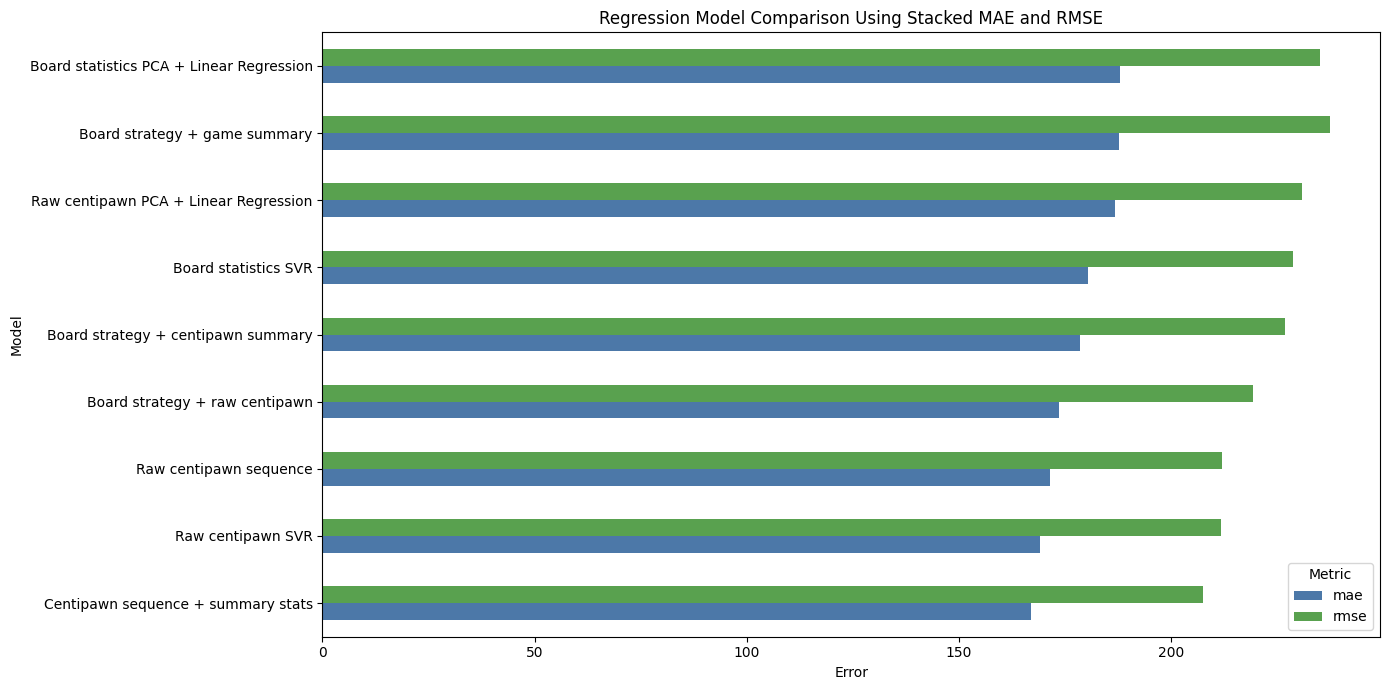

In [20]:
model_comparison_df = pd.DataFrame(
    {
        "model": [
            "Board strategy + game summary",
            "Board statistics SVR",
            "Board statistics PCA + Linear Regression",
            "Raw centipawn sequence",
            "Raw centipawn SVR",
            "Raw centipawn PCA + Linear Regression",
            "Centipawn sequence + summary stats",
            "Board strategy + raw centipawn",
            "Board strategy + centipawn summary",
        ],
        "mae": [
            game_mae,
            board_svr_mae,
            board_pca_lr_mae,
            cp_game_mae,
            centipawn_svr_mae,
            centipawn_pca_lr_mae,
            summary_game_mae,
            combined_game_mae,
            strategy_summary_mae,
        ],
        "rmse": [
            game_rmse,
            board_svr_rmse,
            board_pca_lr_rmse,
            cp_game_rmse,
            centipawn_svr_rmse,
            centipawn_pca_lr_rmse,
            summary_game_rmse,
            combined_game_rmse,
            strategy_summary_rmse,
        ],
        "baseline_mae": [
            board_baseline_mae,
            board_baseline_mae,
            board_baseline_mae,
            cp_baseline_mae,
            cp_baseline_mae,
            cp_baseline_mae,
            summary_baseline_mae,
            combined_baseline_mae,
            strategy_summary_baseline_mae,
        ],
        "baseline_rmse": [
            board_baseline_rmse,
            board_baseline_rmse,
            board_baseline_rmse,
            cp_baseline_rmse,
            cp_baseline_rmse,
            cp_baseline_rmse,
            summary_baseline_rmse,
            combined_baseline_rmse,
            strategy_summary_baseline_rmse,
        ],
    }
)

model_comparison_df["mae_improvement_vs_baseline"] = model_comparison_df["baseline_mae"] - model_comparison_df["mae"]
model_comparison_df["rmse_improvement_vs_baseline"] = model_comparison_df["baseline_rmse"] - model_comparison_df["rmse"]

model_comparison_df = model_comparison_df.sort_values("mae").reset_index(drop=True)
display(model_comparison_df)

plot_df = model_comparison_df.set_index("model")[["mae", "rmse"]]

ax = plot_df.plot(
    kind="barh",
    stacked=False,
    figsize=(14, 7),
    color=["#4C78A8", "#59A14F"]
)

ax.set_title("Regression Model Comparison Using Stacked MAE and RMSE")
ax.set_xlabel("Error")
ax.set_ylabel("Model")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()


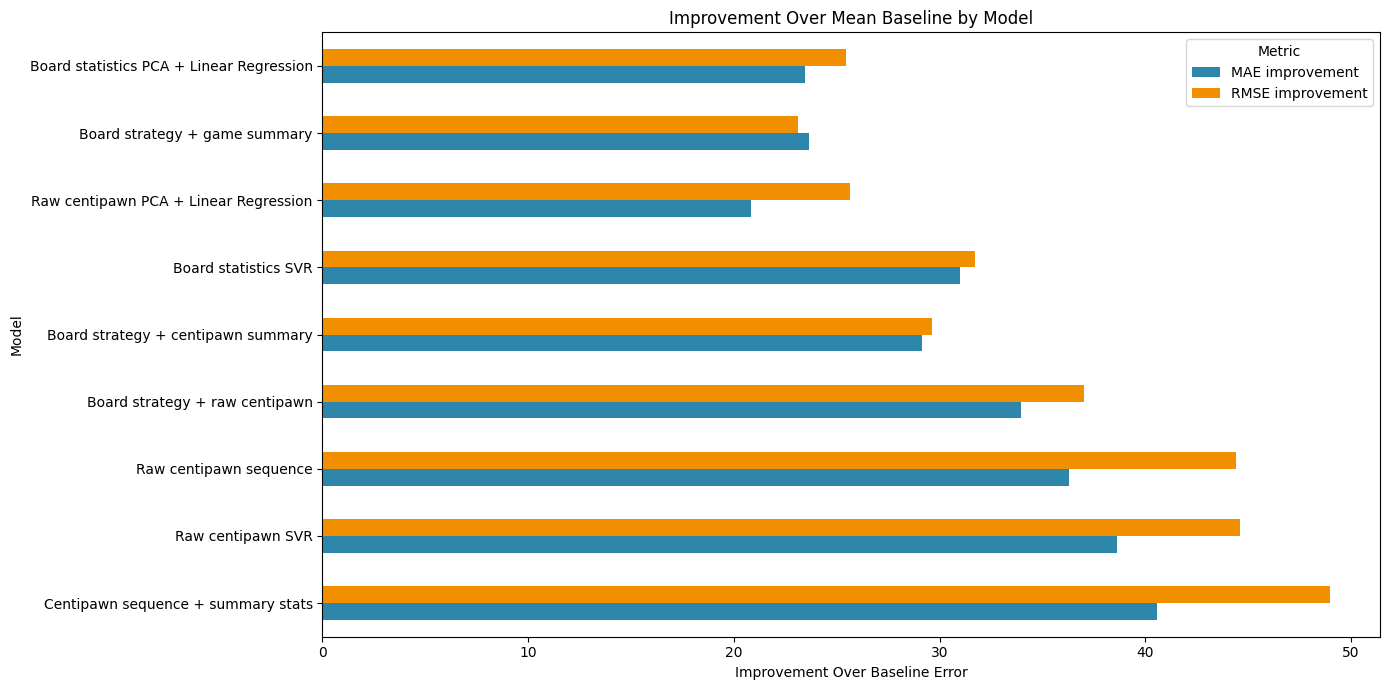

In [ ]:
improvement_plot_df = model_comparison_df.set_index("model")[
    ["mae_improvement_vs_baseline", "rmse_improvement_vs_baseline"]
]

ax = improvement_plot_df.plot(
    kind="barh",
    figsize=(14, 7),
    color=["#2E86AB", "#F18F01"]
)

ax.set_title("Improvement Over Mean Baseline by Model")
ax.set_xlabel("Improvement Over Baseline Error")
ax.set_ylabel("Model")
ax.legend(["MAE improvement", "RMSE improvement"], title="Metric")
plt.tight_layout()
plt.show()
